# Example-34: Synchrosqueezing

In [1]:
# Import

import numpy
import torch

import sys
sys.path.append('..')

from math import pi

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)

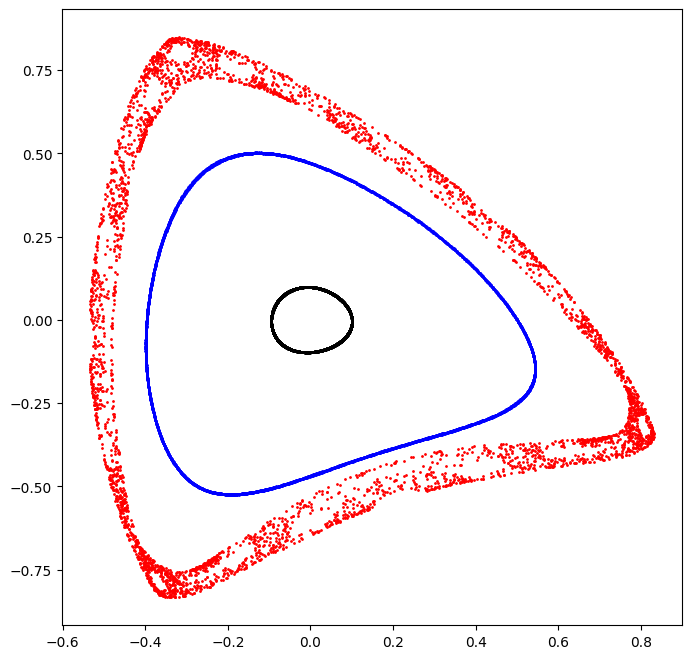

In [2]:
# Set test nonlinear mapping and generate several orbits

dtype = torch.float64
device = torch.device('cpu')

a1, b1 = 0, 1
a2, b2 = 0, 1

f1 = torch.tensor(2.0*numpy.pi*0.38, dtype=dtype, device=device)
f2 = torch.tensor(2.0*numpy.pi*0.41, dtype=dtype, device=device)

cf1, sf1 = f1.cos(), f1.sin()
cf2, sf2 = f2.cos(), f2.sin()

def mapping(x, k):
    q1, p1, q2, p2 = x
    k, = k
    return torch.stack([
        b1*(p1 + k*(q1**2 - q2**2))*sf1 + q1*(cf1 + a1*sf1),
        -((q1*(1 + a1**2)*sf1)/b1) + (p1 + k*(q1**2 - q2**2))*(cf1 - a1*sf1),
        q2*cf2 + (p2*b2 + k*q2*(a2 - 2*q1*b2))*sf2,
        -((q2*(1 + a2**2)*sf2)/b2) + (p2 - 2*k*q1*q2)*(cf2 - a2*sf2)
    ])


count = 2**12

plt.figure(figsize=(8, 8))

k = torch.tensor([1.0], dtype=dtype)

x = torch.tensor([0.10000, 0.0, 0.05, 0.0], dtype=dtype)
orbit = []
for _ in range(count):
    x = mapping(x, k)
    orbit.append(x)
q, p, *_ = torch.stack(orbit).T
qa = torch.clone(q)
pa = torch.clone(p)
za = qa - 1j*pa
plt.scatter(q, p, s =1, color='black')

x = torch.tensor([0.50000, 0.0, 0.05, 0.0], dtype=dtype)
orbit = []
for _ in range(count):
    x = mapping(x, k)
    orbit.append(x)
q, p, *_ = torch.stack(orbit).T
qb = torch.clone(q)
pb = torch.clone(p)
zb = qb - 1j*pb
plt.scatter(q, p, s =1, color='blue')

x = torch.tensor([0.65, 0., 0.25, 0.], dtype=dtype)
orbit = []
for _ in range(count):
    x = mapping(x, k)
    orbit.append(x)
q, p, *_ = torch.stack(orbit).T
qc = torch.clone(q)
pc = torch.clone(p)
zc = qc - 1j*pc
plt.scatter(q, p, s=1, color='red')

plt.show()

In [3]:
# https://github.com/OverLordGoldDragon/ssqueezepy/blob/master/examples/extracting_ridges.py

from ssqueezepy import ssq_cwt
from ssqueezepy import ssq_stft
from ssqueezepy import extract_ridges

from ssqueezepy.visuals import plot
from ssqueezepy.visuals import imshow

def show(x, Tf, ridge_idxs, yticks=None, ssq=False, transform='cwt', show_x=True):
    if show_x:
        plot(x, title="x(t)", show=1, xlabel="T", ylabel="X", w=1, h=0.5)

    ylabel = ("1/F" if (transform == 'cwt' and not ssq) else "F")
    title = "abs({}{}) w/ ridge_idxs".format("SSQ_" if ssq else "", transform.upper())

    ikw = dict(abs=1, cmap='turbo', yticks=yticks, title=title, w=12, h=4)
    pkw = dict(linestyle='--', color='k', xlabel="Time [samples]", ylabel=ylabel, w=1, h=0.5, xlims=(0, Tf.shape[1]))

    imshow(Tf, **ikw, show=0)
    plot(ridge_idxs, **pkw, show=1)


def tf_transforms(x, t, wavelet='morlet', window=None, padtype='wrap',
                  penalty=1, n_ridges=0, cwt_bw=16, stft_bw=16,
                  ssq_cwt_bw=4, ssq_stft_bw=4):
    
    kw_cwt  = dict(t=t, padtype=padtype)
    kw_stft = dict(fs=1/(t[1] - t[0]), padtype=padtype, flipud=1)
    
    Twx, Wx, ssq_freqs_c, scales, *_ = ssq_cwt(x,  wavelet, **kw_cwt)
    
    Tsx, Sx, ssq_freqs_s, Sfs, *_    = ssq_stft(x, window,  **kw_stft)
    Sx, Sfs = Sx[::-1], Sfs[::-1]

    ckw = dict(penalty=penalty, n_ridges=n_ridges, transform='cwt')
    skw = dict(penalty=penalty, n_ridges=n_ridges, transform='stft')
    cwt_ridges      = extract_ridges(Wx,  scales,      bw=cwt_bw,      **ckw)
    ssq_cwt_ridges  = extract_ridges(Twx, ssq_freqs_c, bw=ssq_cwt_bw,  **ckw)
    stft_ridges     = extract_ridges(Sx,  Sfs,         bw=stft_bw,     **skw)
    ssq_stft_ridges = extract_ridges(Tsx, ssq_freqs_s, bw=ssq_stft_bw, **skw)

    show(x, Wx,  cwt_ridges,      scales,      ssq=0, transform='cwt',  show_x=1)
    show(x, Twx, ssq_cwt_ridges,  ssq_freqs_c, ssq=1, transform='cwt',  show_x=0)
    show(x, Sx,  stft_ridges,     Sfs,         ssq=0, transform='stft', show_x=0)
    show(x, Tsx, ssq_stft_ridges, ssq_freqs_s, ssq=1, transform='stft', show_x=0)

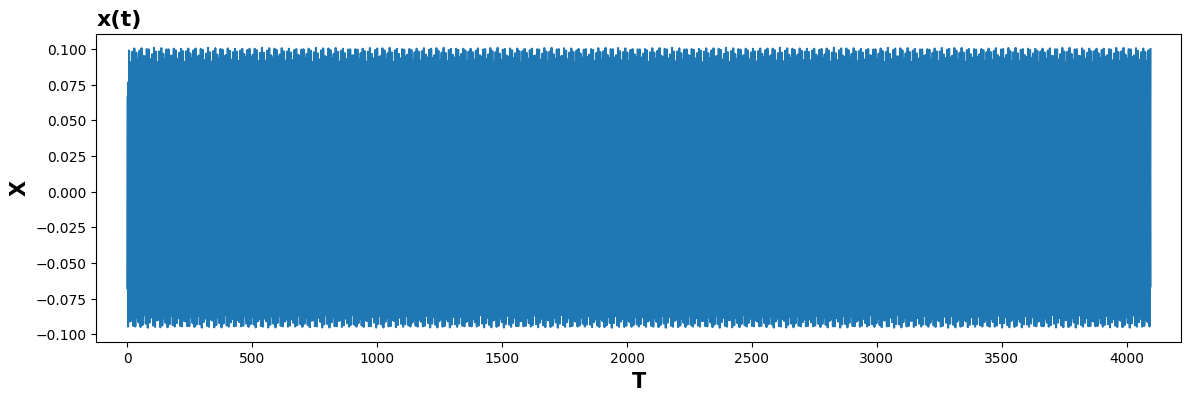

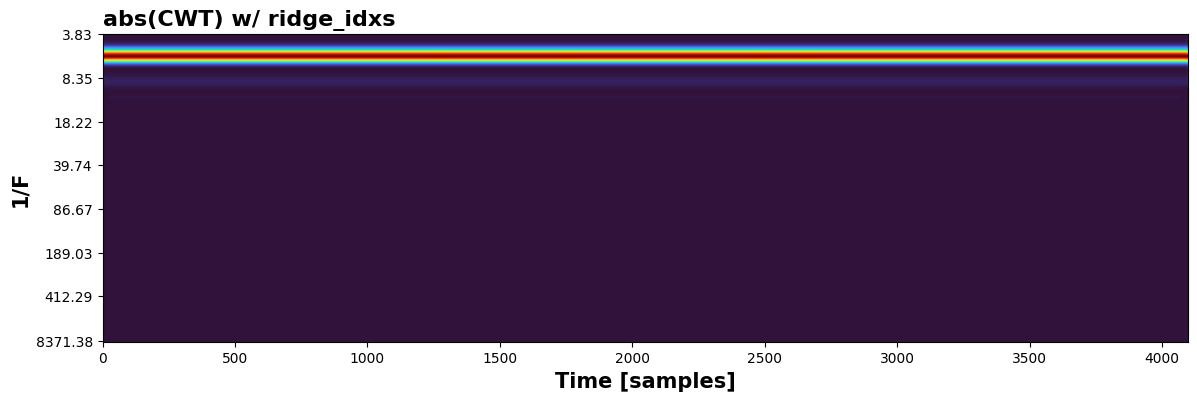

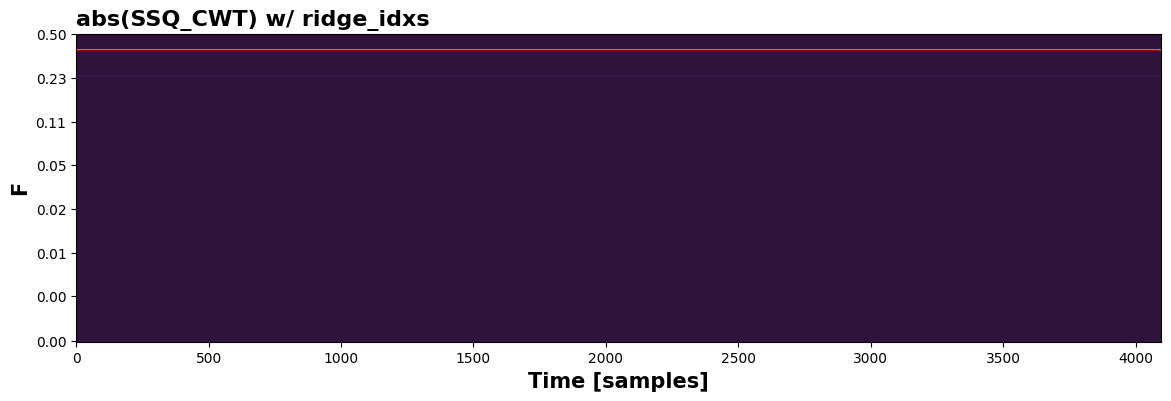

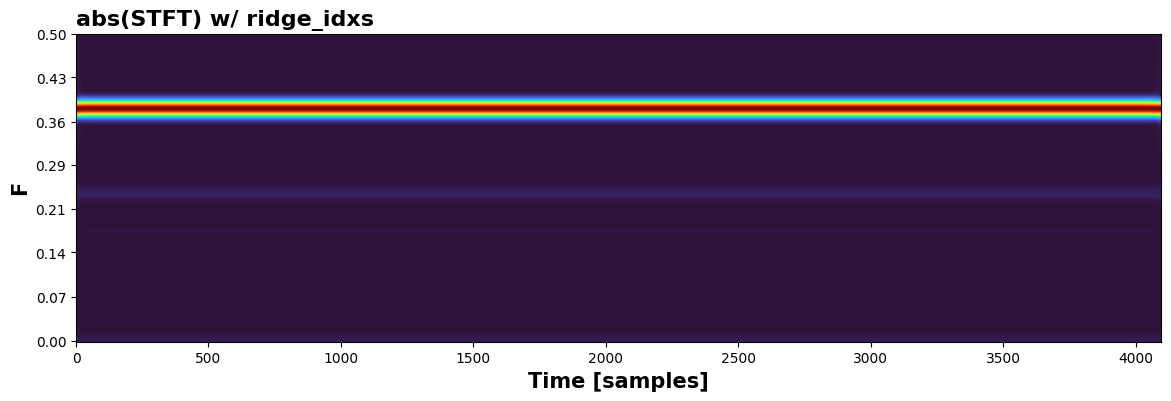

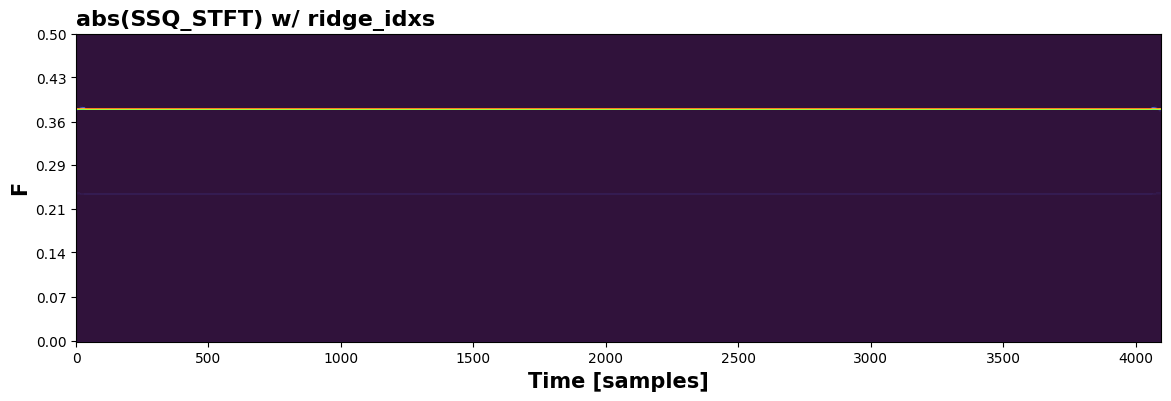

In [4]:
n = 2**12
t = numpy.linspace(0, n, n, endpoint=False)
x = qa[:n].cpu().numpy()
tf_transforms(x, t)

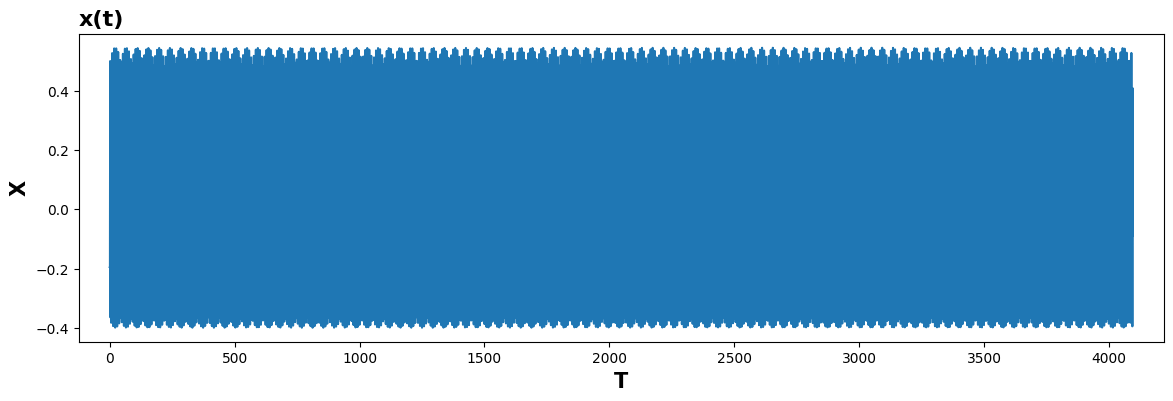

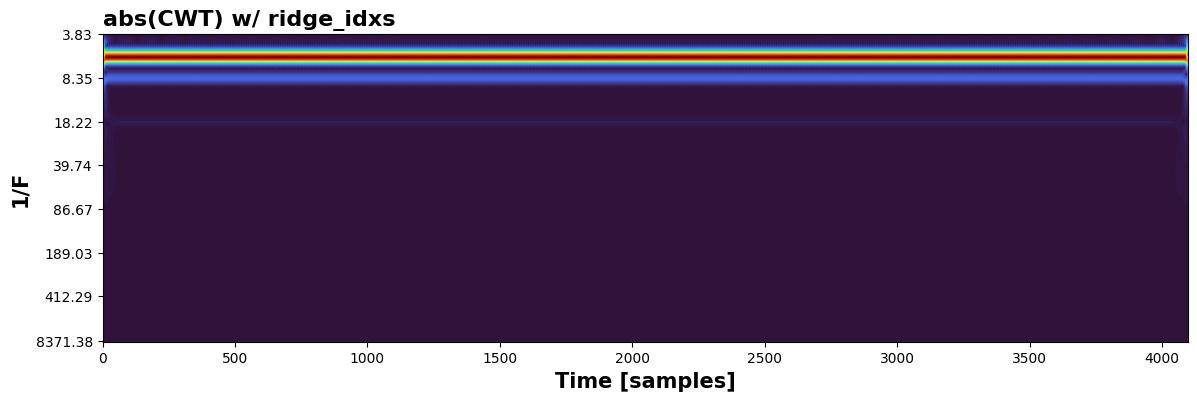

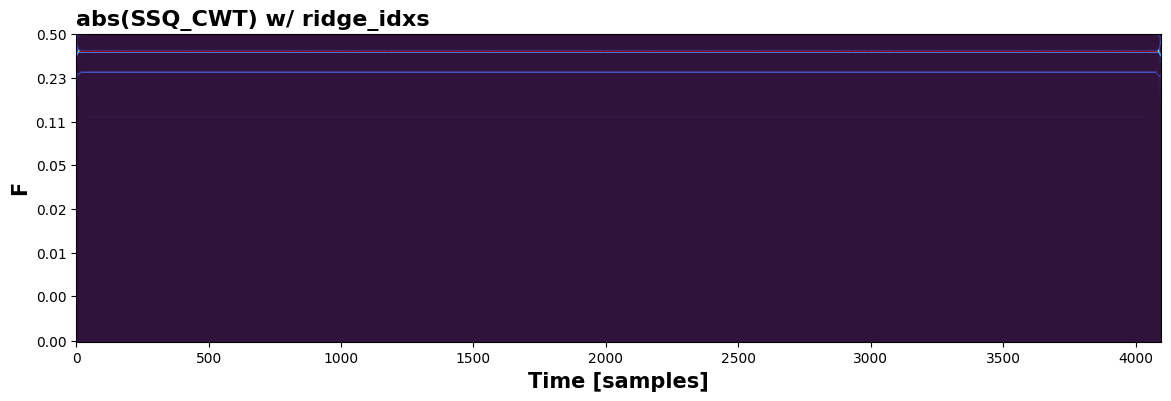

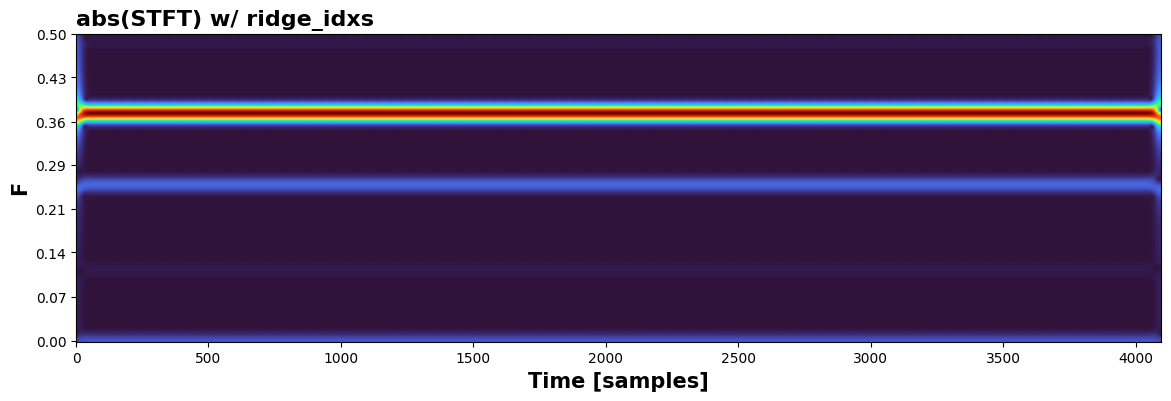

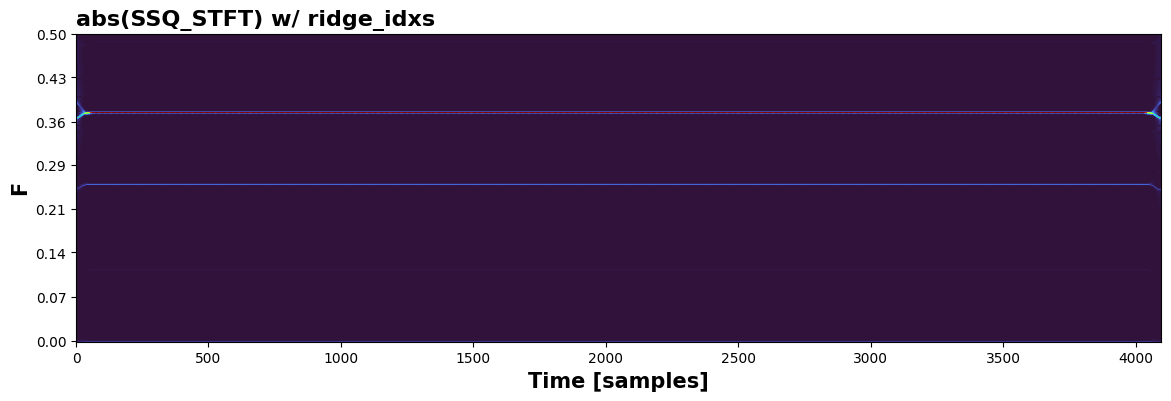

In [5]:
n = 2**12
t = numpy.linspace(0, n, n, endpoint=False)
x = qb[:n].cpu().numpy()
tf_transforms(x, t)

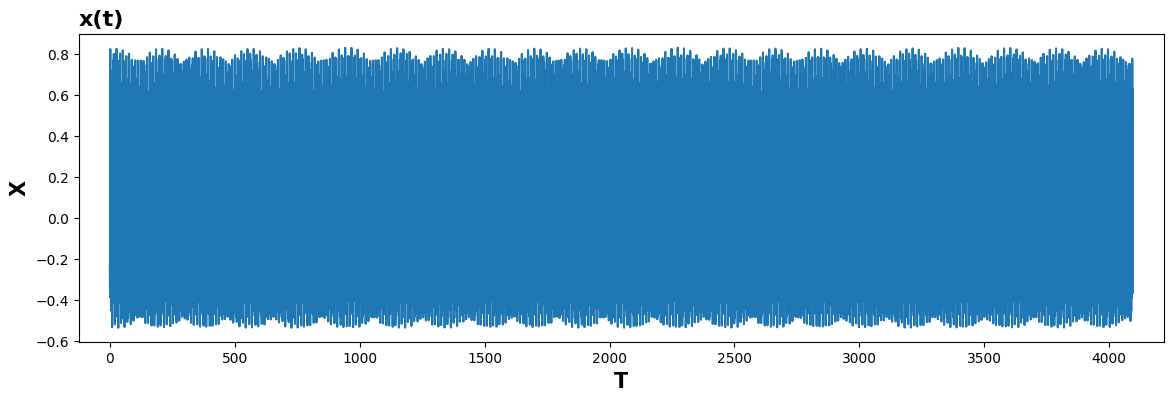

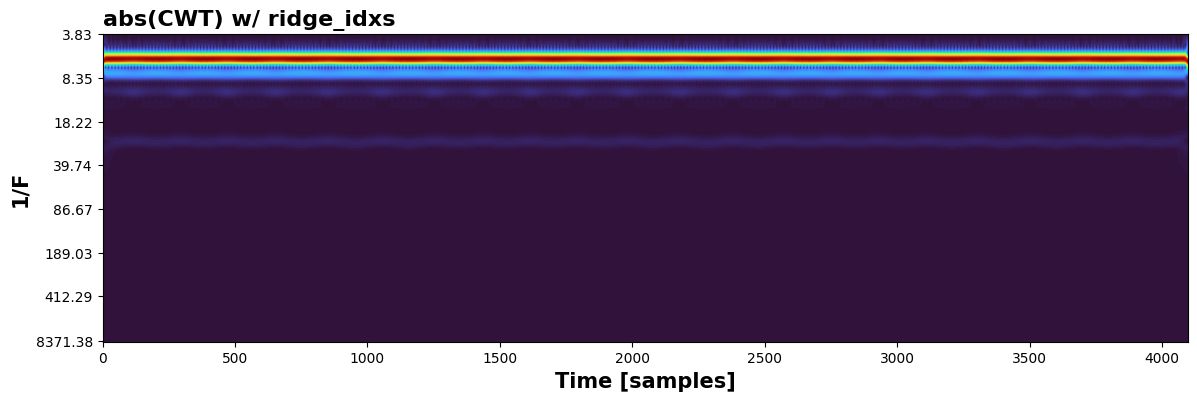

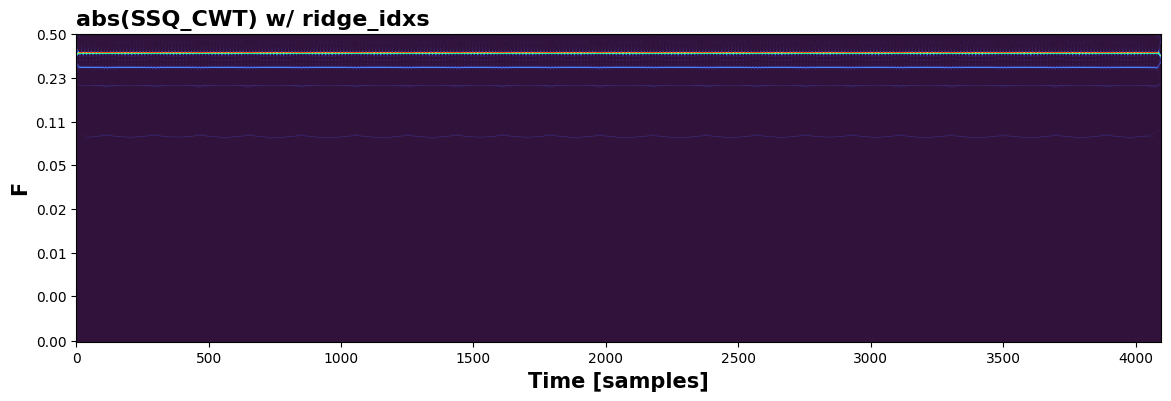

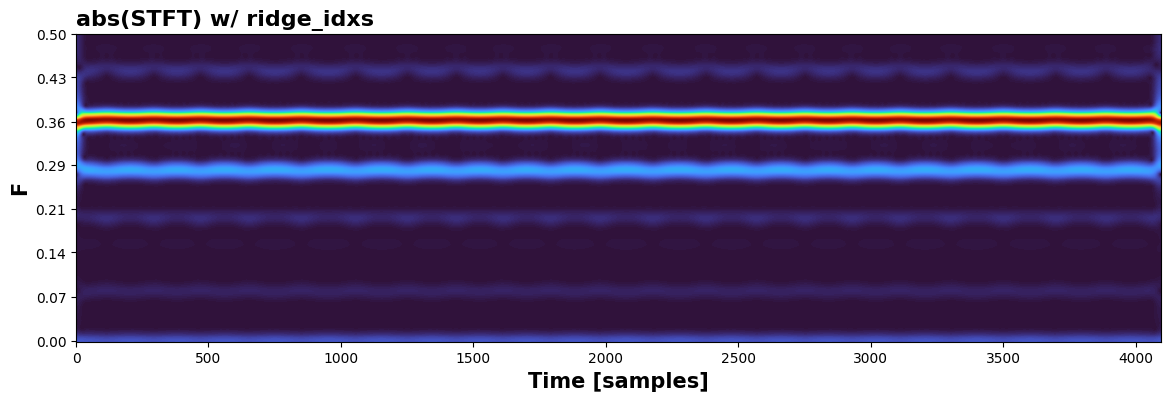

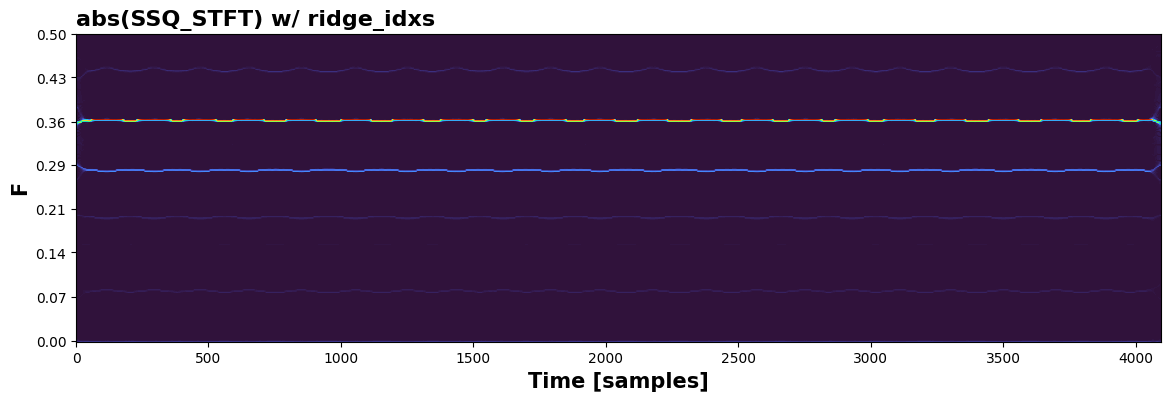

In [6]:
n = 2**12
t = numpy.linspace(0, n, n, endpoint=False)
x = qc[:n].cpu().numpy()
tf_transforms(x, t)